### Packages

In [1]:
# Packages to Install

from statsmodels.regression.rolling import RollingOLS
import pandas_datareader.data as web
import requests
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm
from pypfopt.efficient_frontier import EfficientFrontier
from pypfopt import risk_models
from pypfopt import expected_returns
import pandas as pd
import numpy as np
import datetime as dt
import yfinance as yf
import pandas_ta
from io import StringIO
import warnings
warnings.filterwarnings('ignore')

### Data download and clean-up

Downloading a list of S&P500 companies from Wikipedia and applying some data clean up to it so it's ready<br> 
to be matched with historical price data sourced using yfinance

In [2]:
# Define a function that reads a Wikipedia URL and returns a pandas dataframe 

def read_wikipedia_table(url: str, table_index: int = 0) -> pd.DataFrame:
    """
    Fetches an HTML table from a Wikipedia page and returns it as a pandas DataFrame.

    Parameters
    ----------
    url : str
        The full URL of the Wikipedia page.
    table_index : int, optional
        Which table to return (default is the first table on the page).

    Returns
    -------
    pd.DataFrame
        The extracted table as a DataFrame.
    """
    headers = {"User-Agent": "Mozilla/5.0"}

    response = requests.get(url, headers=headers)
    response.raise_for_status()

    html = response.text
    tables = pd.read_html(StringIO(html))

    if table_index >= len(tables):
        raise IndexError(
            f"Table index {table_index} out of range. "
            f"Page contains {len(tables)} tables."
        )

    return tables[table_index]

In [3]:
# Read the list of S&P 500 companies from Wikipedia 

url = "https://en.wikipedia.org/wiki/List_of_S%26P_500_companies"
sp500 = read_wikipedia_table(url)

print(sp500.head())

  Symbol             Security             GICS Sector  \
0    MMM                   3M             Industrials   
1    AOS          A. O. Smith             Industrials   
2    ABT  Abbott Laboratories             Health Care   
3   ABBV               AbbVie             Health Care   
4    ACN            Accenture  Information Technology   

                GICS Sub-Industry    Headquarters Location  Date added  \
0        Industrial Conglomerates    Saint Paul, Minnesota  1957-03-04   
1               Building Products     Milwaukee, Wisconsin  2017-07-26   
2           Health Care Equipment  North Chicago, Illinois  1957-03-04   
3                   Biotechnology  North Chicago, Illinois  2012-12-31   
4  IT Consulting & Other Services          Dublin, Ireland  2011-07-06   

       CIK      Founded  
0    66740         1902  
1    91142         1916  
2     1800         1888  
3  1551152  2013 (1888)  
4  1467373         1989  


In [4]:
# Define a function to download data from yfiance and apply some clean-up steps 

def prepare_price_data(df: pd.DataFrame, start_date, end_date):
    """
    Cleans ticker symbols and downloads historical price data using yfinance.

    Parameters
    ----------
    df : pd.DataFrame
        DataFrame containing at least a 'Symbol' column.
    start_date : str or pd.Timestamp
        Start date for historical data.
    end_date : str or pd.Timestamp
        End date for historical data.

    Returns
    -------
    pd.DataFrame
        Multi-index DataFrame with cleaned tickers and lowercase OHLCV columns.
    """

    # Some of the symbols contain a dot and this requires further cleaning to avoid issues with yfinance
    # Replace all dots with a dash
    df['Symbol'] = df['Symbol'].str.replace('.', '-', regex=False)

    # Grab a unique list of all S&P 500 stocks
    # Note that this list of stocks is not survivorship bias free
    symbols_list = df['Symbol'].unique().tolist()

    # Ensure dates are timestamps
    end_date = pd.to_datetime(end_date)
    start_date = pd.to_datetime(start_date)

    # Download data using yfinance
    data = yf.download(
        tickers=symbols_list,
        start=start_date,
        end=end_date
    ).stack()

    # Create multi-index with date and ticker
    data.index.names = ['date', 'ticker']

    # Lowercase all column names
    data.columns = data.columns.str.lower()

    return data

In [5]:
# Download the data ending in 2025 and going 8 years back 

end_date = "2025-12-31"
start_date = pd.to_datetime(end_date) - pd.DateOffset(365 * 8)

df = prepare_price_data(sp500, start_date, end_date)
df

[*********************100%***********************]  503 of 503 completed


Price                   close        high         low        open       volume
date       ticker                                                             
2018-01-02 A        63.667709   63.940841   63.422832   63.498180    1047800.0
           AAPL     40.304169   40.313530   39.602250   39.812828  102223600.0
           ABBV     69.343712   69.688984   68.174005   68.448815    4561300.0
           ABT      50.822941   51.177379   49.984392   50.312896   10112800.0
           ACGL     27.988113   28.926334   27.940569   28.910486    1333500.0
...                       ...         ...         ...         ...          ...
2025-12-30 XYZ      65.540001   65.989998   65.449997   65.830002    2958800.0
           YUM     151.481842  151.959651  150.755195  150.984136    1158600.0
           ZBH      90.790001   90.919998   89.879997   90.180000     934500.0
           ZBRA    246.740005  247.039993  243.320007  244.619995     492400.0
           ZTS     125.872520  127.057456  124.916596  125.016176    3230200.0

[989847 rows x 5 columns]

### Calculate technical indicators for each stock

For each stock calculate a series of technical indicators focused on measuring stock volatility that will be used for<br>
unsupervised learning 

#### 📈 Garman–Klass Volatility (GK)

The Garman–Klass estimator is a range-based volatility measure that uses
open, high, low, and close (OHLC) prices to produce a more efficient estimate
of realized volatility than simple close-to-close methods.


$$
GK = \sqrt{
0.5 \cdot (\ln(High/Low))^2
-
(2\ln(2) - 1)(\ln(Close/Open))^2
}
$$

Where:

- \(Open\) = opening price  
- \(High\) = highest price of the session  
- \(Low\) = lowest price of the session  
- \(Close\) = closing price  

#### ⭐ Why the Garman–Klass Volatility Estimator Is Useful

- **More efficient than close-to-close volatility:**  
  It uses the full intraday range (high–low), which contains more information
  about price variability than just the closing prices.

- **Captures intraday volatility:**  
  The high–low range reflects the true amplitude of price movement within the
  session, making GK a strong proxy for realized volatility.

- **Easy to compute:**  
  Requires only OHLC data, which is widely available for stocks, forex, and
  other markets.

- **Well-suited for continuous markets:**  
  Works particularly well in markets with fewer overnight gaps (e.g., forex),
  where the assumptions behind the estimator hold more closely.

---

#### ⚠️ Limitations of the Garman–Klass Estimator

- **Sensitive to overnight gaps:**  
  GK assumes continuous price evolution within the session. Large jumps between
  the previous close and the next open (common in stocks) can distort the
  estimate.

- **Assumes no drift during the session:**  
  The estimator performs best when intraday directional trends are small.
  Strong trending days can bias the volatility estimate.

- **Not ideal for illiquid assets:**  
  Assets with sparse trading or irregular price updates may produce unreliable
  high–low ranges.

- **Better alternatives exist for gap-heavy markets:**  
  For equities with frequent overnight jumps, estimators like
  *Rogers–Satchell* or *Yang–Zhang* may be more robust.

In [6]:
# Garman–Klass volatility estimator (per‑row calculation using NumPy)

df['garman_klass_vol'] = ((np.log(df['high'])-np.log(df['low']))**2)/2-(2*np.log(2)-1)*((np.log(df['close'])-np.log(df['open']))**2)

#### 📈 Relative Strength Index (RSI)

The **Relative Strength Index (RSI)** is a momentum oscillator that measures the magnitude of recent price changes to determine whether a stock is **overbought** or **oversold**.  
It ranges from **0 to 100** and is typically calculated using a **14‑period** lookback window.

The RSI is built from the ratio of average gains to average losses over the lookback period.

$$
RSI = 100 - \frac{100}{1 + RS}
$$

Where:

$$
RS = \frac{\text{Average Gain over } n}{\text{Average Loss over } n}
$$

and the average gains/losses are computed as:

$$
\text{Average Gain} = \frac{1}{n} \sum_{i=1}^{n} \max(\Delta P_i, 0)
$$

$$
\text{Average Loss} = \frac{1}{n} \sum_{i=1}^{n} \max(-\Delta P_i, 0)
$$

with

$$
\Delta P_i = P_i - P_{i-1}
$$

#### ⭐ Why the RSI Is Useful

- **Identifies momentum exhaustion**  
  Highlights when price movements have become stretched, helping detect potential reversals.

- **Simple interpretation**  
  RSI > 70 often signals overbought conditions; RSI < 30 signals oversold conditions.

- **Effective in range‑bound markets**  
  Particularly useful for mean‑reversion strategies.

- **Supports regime classification**  
  Persistent RSI > 60 suggests strong momentum; RSI < 40 suggests weakness — helpful for S&P 500 screening.

- **Divergence detection**  
  RSI divergences (price makes new highs/lows but RSI does not) can signal early trend shifts.

---

#### ⚠️ Limitations of the RSI Estimator

- **False signals in trending markets**  
  RSI can remain overbought or oversold for long periods during strong trends.

- **Sensitive to lookback period**  
  Shorter periods increase noise; longer periods delay signals.

- **Not a standalone indicator**  
  RSI does not measure trend direction or volatility. It works best when combined with trend filters (e.g., EMAs) and volatility measures (e.g., ATR, Garman–Klass).

- **Lagging nature**  
  RSI is based on averages of past gains/losses, so it reacts to price changes rather than predicting them.

In [7]:
# RSI Calculation

# We compute the Relative Strength Index (RSI) using a **14‑period lookback window**
# The calculation is applied **per ticker**, so we group the DataFrame by the ticker level (level 1)

df['rsi'] = df.groupby(level=1)['close'].transform(lambda x: pandas_ta.rsi(close=x, length=14))

#### 📊 Bollinger Bands (BB)

Bollinger Bands are a volatility‑based indicator composed of three lines:

- **Middle Band**: typically a 20‑period Simple Moving Average (SMA)  
- **Upper Band**: SMA + (k × standard deviation)  
- **Lower Band**: SMA − (k × standard deviation)

The **Middle Band** is the \( n \)-period Simple Moving Average (SMA):

$$
\text{Middle Band}_t = SMA_n(P_t)
$$

The **Standard Deviation** over the same window is:

$$
\sigma_t = \sqrt{
\frac{1}{n} \sum_{i=0}^{n-1} (P_{t-i} - \text{Middle Band}_t)^2
}
$$

The **Upper** and **Lower** Bollinger Bands are then defined as:

$$
\text{Upper Band}_t = \text{Middle Band}_t + k \cdot \sigma_t
$$

$$
\text{Lower Band}_t = \text{Middle Band}_t - k \cdot \sigma_t
$$

The standard parameters are \( n = 20 \) and \( k = 2 \).

---

#### ⭐ Why Bollinger Bands Are Useful

- **Adaptive to volatility**  
  The bands widen during high volatility and tighten during low volatility, giving a dynamic view of market conditions.

- **Identifies price extremes**  
  Price touching the upper band may indicate overextension; touching the lower band may indicate undervaluation.

- **Supports mean‑reversion strategies**  
  Moves outside the bands followed by re‑entry often signal a return toward the middle SMA.

- **Detects volatility squeezes**  
  Narrow bands indicate low volatility and often precede strong directional moves — useful for screening S&P 500 breakout candidates.

- **Works well with trend filters**  
  Combining Bollinger Bands with moving averages or MACD helps distinguish between trend continuation and mean‑reversion setups.

---

#### ⚠️ Limitations of Bollinger Bands

- **Not a standalone signal**  
  Price touching a band does not guarantee reversal; strong trends can ride the bands for long periods.

- **Parameter sensitivity**  
  The standard 20‑period SMA and 2‑standard‑deviation settings may not suit all stocks or market regimes.

- **False mean‑reversion signals**  
  In trending markets, interpreting band touches as overbought/oversold can lead to premature entries.

- **Assumes symmetric volatility**  
  Standard deviation‑based bands implicitly assume normally distributed price movements, which financial returns often violate.

---

In [8]:
# Create a function that computes the Bollinger Bands over a period of time (will keep a 20 SMA as default)

def compute_bbands(series, length=20):
    """
    Compute Bollinger Bands (low, mid, high) for a price series.
    Uses log1p transformation to stabilize variance.
    Returns a DataFrame with three named columns.
    """
    bb = pandas_ta.bbands(close=np.log1p(series), length=length)
    out = bb.iloc[:, :3].copy()
    out.columns = ['bb_low', 'bb_mid', 'bb_high']
    return out

# Apply per ticker (level=1), returns a MultiIndex DataFrame
bb_cols = df.groupby(level=1)['close'].apply(compute_bbands)

# Drop the group level so the index matches df
bb_cols.index = bb_cols.index.droplevel(0)

# Assign all three columns at once, aligned by index
df[['bb_low', 'bb_mid', 'bb_high']] = bb_cols

#### 📐 Average True Range (ATR)

The Average True Range (ATR) is a volatility indicator that measures how much an asset typically moves over a given period.  
It is based on the **True Range (TR)**, which captures both intraday volatility and overnight gaps:

The **True Range (TR)** for each period is defined as:

$$
TR_t = \max \Big(
High_t - Low_t,\ 
|High_t - Close_{t-1}|,\ 
|Low_t - Close_{t-1}|
\Big)
$$

The **Average True Range (ATR)** over a window of \( n \) periods is:

$$
ATR_n = \frac{1}{n} \sum_{i=1}^{n} TR_i
$$

A common choice is \( n = 14 \), following Wilder’s original definition.

---

#### ⭐ Why the ATR Is Useful

- **Captures real volatility**  
  ATR accounts for both intraday movement and price gaps, giving a more complete picture of volatility than simple high–low ranges.

- **Helps size positions and manage risk**  
  Traders often scale position sizes or stop‑loss distances using ATR to adapt to changing volatility.

- **Useful for breakout detection**  
  Large ATR expansions often accompany strong directional moves, making it helpful for identifying high‑momentum stocks in the S&P 500.

- **Regime identification**  
  Rising ATR indicates increasing uncertainty or trend acceleration; falling ATR suggests consolidation or low‑volatility environments.

---

#### ⚠️ Limitations of the ATR Estimator

- **Does not indicate direction**  
  ATR measures volatility only — it cannot tell whether price is trending up or down.

- **Lagging indicator**  
  Because ATR is a moving average of past ranges, it reacts to volatility changes rather than predicting them.

- **Parameter sensitivity**  
  Short ATR periods can be noisy; long periods may smooth out important volatility shifts.

- **Not a standalone signal**  
  ATR works best when combined with trend indicators (e.g., EMAs, MACD) or volatility‑based tools (e.g., Bollinger Bands, Garman–Klass).

In [9]:
# Compute the ATR for each ticker and normalize it

def compute_atr(stock_data):
    """
    Compute the Average True Range (ATR) for a given stock's price history.
    Uses a 14‑period window (Wilder's default) and returns a normalized ATR
    so that volatility is comparable across different tickers.
    """
    atr = pandas_ta.atr(
        high=stock_data['high'],
        low=stock_data['low'],
        close=stock_data['close'],
        length=14
    )
    
    # Normalize ATR: (ATR - mean) / std
    return atr.sub(atr.mean()).div(atr.std())

df['atr'] = df.groupby(level=1, group_keys=False).apply(compute_atr)

#### 📉 Moving Average Convergence Divergence (MACD)

The Moving Average Convergence Divergence (MACD) is a trend‑following momentum indicator that measures the relationship between two exponential moving averages (EMAs).  
It consists of three components:

- **MACD Line**: difference between fast and slow EMAs  
- **Signal Line**: EMA of the MACD Line  
- **Histogram**: distance between MACD and Signal Line  

The **MACD Line** is defined as:

$$
MACD_t = EMA_{n_{\text{fast}}}(P_t) - EMA_{n_{\text{slow}}}(P_t)
$$

The **Signal Line** is an EMA of the MACD Line:

$$
\text{Signal}_t = EMA_{n_{\text{signal}}}(MACD_t)
$$

The **MACD Histogram** is:

$$
\text{Histogram}_t = MACD_t - \text{Signal}_t
$$

Standard parameters:

- Fast EMA period:

$$
n_{\text{fast}} = 12
$$

- Slow EMA period:

$$
n_{\text{slow}} = 26
$$

- Signal line period:

$$
n_{\text{signal}} = 9
$$
---

#### ⭐ Why the MACD Is Useful

- **Captures both trend and momentum**  
  The MACD Line reflects momentum shifts, while the Signal Line smooths noise, making trend changes easier to identify.

- **Effective for spotting crossovers**  
  A MACD–Signal crossover often marks a momentum shift — useful for timing entries/exits in trending markets.

- **Identifies trend strength**  
  A widening histogram indicates strengthening momentum; a contracting histogram signals weakening momentum.

- **Works well with other indicators**  
  Combining MACD with volatility measures (ATR, Bollinger Bands) or trend filters (EMAs) improves robustness.

- **Useful for S&P 500 screening**  
  MACD helps highlight stocks transitioning into or out of strong momentum phases.

---

#### ⚠️ Limitations of the MACD Indicator

- **Lagging nature**  
  MACD is based on EMAs, so it reacts to price changes rather than predicting them.

- **Whipsaws in range‑bound markets**  
  Frequent crossovers can generate false signals when price lacks clear direction.

- **Parameter sensitivity**  
  Different EMA lengths can drastically change the signal; the standard 12/26/9 may not suit all assets.

- **Not a volatility measure**  
  MACD shows momentum, not risk — it should be paired with ATR, Bollinger Bands, or Garman–Klass for a fuller picture.

In [10]:
def compute_macd(close):
    """
    Compute the MACD indicator for a given closing price series.
    Uses pandas_ta's default MACD parameters (12, 26, 9) and returns
    a normalized MACD line so that momentum is comparable across tickers.
    """
    # pandas_ta.macd returns 3 columns: MACD, Signal, Histogram
    macd = pandas_ta.macd(close=close).iloc[:, 0]  # MACD line only

    # Normalize MACD: (MACD - mean) / std
    return macd.sub(macd.mean()).div(macd.std())

df['macd'] = df.groupby(level=1, group_keys=False)['close'].apply(compute_macd)

#### 💵 Dollar Volume

Dollar Volume measures the total monetary value traded for a stock during a given period.  
It is computed as the product of the adjusted closing price and the number of shares traded.  
This makes it a direct and intuitive proxy for **liquidity** and **market participation**.

The daily dollar volume is defined as:

$$
\text{Dollar Volume}_t = \text{Price}_t \times \text{Volume}_t
$$

In practice, it is often scaled by \(10^6\) for readability:

$$
\text{Dollar Volume (millions)}_t = \frac{\text{Price}_t \times \text{Volume}_t}{10^6}
$$

---

#### ⭐ Why Dollar Volume Is Useful

- **A superior measure of liquidity**  
  Unlike raw volume, dollar volume accounts for both price and shares traded, giving a more accurate picture of how much capital flows through a stock.

- **Helps filter tradable assets**  
  Many strategies exclude stocks with low dollar volume to avoid slippage and execution risk.

- **Stable across different price levels**  
  A stock trading 1M shares at \$10 is not equivalent to one trading 1M shares at \$300 — dollar volume captures this difference.

- **Useful for weighting and ranking**  
  Liquidity‑weighted portfolios, turnover analysis, and market participation metrics all rely on dollar volume.

- **Essential for multi‑asset universes**  
  When comparing hundreds of tickers (e.g., S&P 500), dollar volume provides a consistent liquidity baseline.

---

#### ⚠️ Limitations of Dollar Volume

- **Not a volatility measure**  
  High dollar volume does not imply stable or predictable price movement.

- **Can be distorted by extreme price moves**  
  Sudden price spikes inflate dollar volume even if actual trading activity hasn’t changed.

- **Does not capture order book depth**  
  Dollar volume shows *how much traded*, not *how easily* large orders can be executed.

- **Not adjusted for float or market cap**  
  Two stocks with identical dollar volume may have very different liquidity profiles depending on their share structure.

In [11]:
# Calculate an indicator for the dollar volume 

df['dollar_volume'] = (df['close']*df['volume'])/1e6

In [12]:
# Check the final dataset with all the indicators 

df.xs('AAPL', level=1).sort_index(level=0, ascending=True).head()

Price,close,high,low,open,volume,garman_klass_vol,rsi,bb_low,bb_mid,bb_high,atr,macd,dollar_volume
date,,,,,,,,,,,,,
2018-01-02,40.304169,40.313530,39.602250,39.812828,102223600.0,0.000100,NaN,NaN,NaN,NaN,NaN,NaN,4120.037220
2018-01-03,40.297150,40.839968,40.233980,40.367342,118071600.0,0.000111,0.000000,NaN,NaN,NaN,NaN,NaN,4757.948936
2018-01-04,40.484333,40.587282,40.262059,40.369685,89738400.0,0.000029,67.227938,NaN,NaN,NaN,NaN,NaN,3632.999272
2018-01-05,40.945251,41.031820,40.489005,40.580254,94640000.0,0.000058,88.223153,NaN,NaN,NaN,NaN,NaN,3875.058599
2018-01-08,40.793179,41.087983,40.694907,40.793179,82271200.0,0.000046,71.864626,NaN,NaN,NaN,NaN,NaN,3356.103752


#### Further aggregation and filtering

Applying further aggregation from daily-level to monthly-level and filter for top 150 most liquid stocks to reduce training time 

In [13]:
# Convert the daily level of granularity to month-end level 

# For dollar volume take the average dollar volume for each month 
# For the remaining indicators take the last value of the month (GK, RSI, BB, ATR, MACD)

# Extract all the indicators calculated previously and exclude the raw data
 
last_cols = [c for c in df.columns.unique(0) if c not in ['dollar_volume', 'volume', 'open',
                                                          'high', 'low']]

data = (pd.concat(# Unstack each ticker and resample dollar volume to month with mean -> stack it back as a df 
                  [df.unstack('ticker')['dollar_volume'].resample('ME').mean().stack('ticker').to_frame('dollar_volume'),
                  # Unstack dataframe for last_cols list and resample entire list to take last value of each month -> stack it back as df 
                   df.unstack()[last_cols].resample('ME').last().stack('ticker')],
                  axis=1)).dropna()

# Data check

data.head()

dollar_volume      close  garman_klass_vol        rsi  \
date       ticker                                                          
2018-02-28 A          216.721278  64.600143          0.000157  48.366010   
           AAPL      7599.690589  41.845165          0.000087  63.549821   
           ABBV       595.454563  82.204002          0.000359  56.243780   
           ABT        386.534464  52.403664          0.000108  56.058615   
           ACGL        47.112687  27.969095          0.000128  46.507603   

                     bb_low    bb_mid   bb_high       atr      macd  
date       ticker                                                    
2018-02-28 A       4.141189  4.200810  4.260431 -1.122016 -0.291737  
           AAPL    3.604700  3.696022  3.787344 -1.341647 -0.176728  
           ABBV    4.350892  4.412045  4.473197  0.274146  0.918213  
           ABT     3.908135  3.961432  4.014729 -1.357380 -0.081074  
           ACGL    3.337312  3.369952  3.402593 -0.900814 -0.357283

In [14]:
# Use loc to select dollar volume column only and calculate the 5-year rolling average for each stock 

data['dollar_volume'] = (data.loc[:, 'dollar_volume'].unstack('ticker').rolling(5*12, min_periods=12).mean().stack())

# Create a new column to rank for each month the dollar volume (using this rank to filter for top 150)

data['dollar_vol_rank'] = (data.groupby('date')['dollar_volume'].rank(ascending=False))

# Filter for top 150 for each month and drop dollar_volume and dollar_vol_rank

data = data[data['dollar_vol_rank']<150].drop(['dollar_volume', 'dollar_vol_rank'], axis=1)

data.head()

close  garman_klass_vol        rsi    bb_low  \
date       ticker                                                      
2019-01-31 AAPL     39.527100          0.000353  59.720366  3.557594   
           ABBV     59.502758          0.000419  40.109141  4.064421   
           ABT      64.544106          0.000151  59.373419  4.091119   
           ACN     138.912292          0.000067  59.922283  4.839709   
           ADBE    247.820007          0.000148  59.029843  5.410468   

                     bb_mid   bb_high       atr      macd  
date       ticker                                          
2019-01-31 AAPL    3.625593  3.693592 -1.165779 -0.347758  
           ABBV    4.159637  4.254853 -0.428147 -0.920190  
           ABT     4.137697  4.184275 -0.557467  0.142271  
           ACN     4.901748  4.963786 -1.177476  0.133741  
           ADBE    5.478527  5.546587 -1.041986  0.277206

#### Adding extra features to capture momentum patterns

Compute historical returns over 1,2,3,6,9 and 12 monthly periods 

In [15]:
def calculate_returns(df):
    """
    Compute forward-looking annualized returns over multiple monthly horizons
    (1, 2, 3, 6, 9, and 12 months) for each ticker.

    For each lag 'm' in months:
    - Compute the percentage change over 'm' periods.
    - Winsorize extreme outliers by clipping returns to the 0.5% and 99.5% quantiles.
    - Convert the m‑month return into an annualized rate:
          (1 + return)^(1/m) - 1
      so that all horizons are comparable on the same scale.

    Returns:
        The input DataFrame with new columns:
        return_1m, return_2m, return_3m, return_6m, return_9m, return_12m
    """
    outlier_cutoff = 0.005
    lags = [1, 2, 3, 6, 9, 12]

    for lag in lags:
        df[f'return_{lag}m'] = (
            df['close']
            .pct_change(lag)
            .pipe(lambda x: x.clip(
                lower=x.quantile(outlier_cutoff),
                upper=x.quantile(1 - outlier_cutoff)
            ))
            .add(1)
            .pow(1 / lag)
            .sub(1)
        )
    return df

data = data.groupby(level=1, group_keys=False).apply(calculate_returns).dropna()

data.head()

close  garman_klass_vol        rsi    bb_low  \
date       ticker                                                      
2020-01-31 AAPL     74.608574          0.000533  52.961715  4.284292   
           ABBV     63.514980          0.000115  27.244743  4.170257   
           ABT      78.315132          0.000153  46.622773  4.332023   
           ACN     188.716354          0.000273  45.383511  5.237360   
           ADBE    351.140015          0.000161  62.984284  5.805300   

                     bb_mid   bb_high       atr      macd  return_1m  \
date       ticker                                                      
2020-01-31 AAPL    4.334739  4.385186 -0.918540  0.439820   0.054010   
           ABBV    4.230085  4.289913 -1.165151 -0.715917  -0.072570   
           ABT     4.380803  4.429584 -1.048554  0.401874   0.007484   
           ACN     5.257198  5.277035 -1.072542  0.059527  -0.021687   
           ADBE    5.847616  5.889933 -1.298629  0.735675   0.064674   

                   return_2m  return_3m  return_6m  return_9m  return_12m  
date       ticker                                                          
2020-01-31 AAPL     0.076164   0.076627   0.065435   0.050566    0.054365  
           ABBV    -0.032533   0.010633   0.037968   0.007064    0.005453  
           ABT      0.011983   0.015313   0.001451   0.011508    0.016247  
           ACN      0.011967   0.035713   0.012016   0.013929    0.025862  
           ADBE     0.065096   0.081056   0.027233   0.021777    0.029466

#### Download the Fama-Frech factors and calculate rolling factor betas 

#### 📚 Fama–French Factors

The **Fama–French factors** are a set of systematic risk factors developed by Eugene Fama and Kenneth French to explain stock returns beyond the traditional market beta.  
They extend the Capital Asset Pricing Model (CAPM) by recognizing that certain groups of stocks consistently earn higher or lower returns due to shared characteristics.

The most commonly used specification is the **Fama–French 3‑Factor Model**, later expanded to 5 and 6 factors.

---

#### 📐 Core Fama–French Factors

The classic **3‑factor model** includes:

1. **Market (MKT)**  
   Excess return of the market over the risk‑free rate.  
   Captures broad market exposure.

2. **Size (SMB: Small Minus Big)**  
   The return difference between small‑cap and large‑cap stocks.  
   Reflects the size premium: small firms tend to outperform large ones.

3. **Value (HML: High Minus Low)**  
   The return difference between high book‑to‑market (value) and low book‑to‑market (growth) stocks.  
   Captures the value premium.

The **5‑factor model** adds:

4. **Profitability (RMW: Robust Minus Weak)**  
   Firms with high operating profitability outperform those with weak profitability.

5. **Investment (CMA: Conservative Minus Aggressive)**  
   Firms that invest conservatively outperform those that invest aggressively.

A **6th factor**, **Momentum (MOM)**, is often included in practice.

---

#### ⭐ Why Fama–French Factors Matter

- They provide a **structured way to decompose returns** into systematic components.  
- They help identify whether a stock’s performance is driven by:
  - market exposure  
  - size characteristics  
  - value/growth profile  
  - profitability  
  - investment behavior  
  - momentum  
- They are widely used in:
  - portfolio construction  
  - risk modeling  
  - performance attribution  
  - factor‑based investing  
  - academic research  

---

#### 🧠 Using Fama–French Factors in Unsupervised Learning

Fama–French factors are extremely useful in unsupervised learning pipelines because they provide **economically meaningful structure** to the data.

Here are the main ways they help:

#### **1. Feature Engineering for Clustering**
Rolling factor betas (e.g., 36‑month regressions) create a compact representation of each stock’s behavior:

- β\_MKT  
- β\_SMB  
- β\_HML  
- β\_RMW  
- β\_CMA  
- β\_MOM  

These betas become **stable, interpretable features** for clustering algorithms like k‑means, HDBSCAN, or spectral clustering.

Stocks cluster naturally into groups such as:

- high‑beta growth stocks  
- defensive value stocks  
- small‑cap momentum stocks  
- quality/profitable firms  

This is far more meaningful than clustering raw returns.

---

#### **2. Dimensionality Reduction**
Factor betas reduce noisy price data into a **low‑dimensional economic space**.  
Techniques like PCA, UMAP, or t‑SNE work better on factor‑based features than on raw returns.

---

#### **3. Regime Detection**
Changes in factor exposures over time can reveal:

- market regime shifts  
- style rotations (value → growth, small → large)  
- volatility cycles  

Unsupervised models can detect these transitions without labels.

---

#### **4. Improving Interpretability**
Clusters based on factor betas are **economically interpretable**, which is rare in unsupervised learning.  
Instead of opaque clusters, you get:

- “High‑momentum small caps”  
- “Low‑beta defensive stocks”  
- “Aggressive investment growth firms”  

This makes the results actionable.

---

#### ⚠️ Limitations

- Factor betas require **long rolling windows** (e.g., 36–60 months), which reduces sample size.  
- Betas can be unstable during crises or structural breaks.  
- Factors explain systematic risk, not idiosyncratic behavior.  
- Using too many factors can introduce noise rather than structure.

---

In [16]:
# Download the Fama–French 5-Factor dataset (monthly frequency by default)

# DataReader returns a dictionary; table [0] contains the factor returns.

factor_data = web.DataReader(
    'F-F_Research_Data_5_Factors_2x3',
    'famafrench',
    start='2010'
)[0].drop('RF', axis=1)   # Drop the risk-free rate (not needed for beta calc here)

# Convert PeriodIndex (e.g., 2010-01) to a proper Timestamp index
factor_data.index = factor_data.index.to_timestamp()

# Ensure monthly alignment with previous dataset and convert percent returns to decimals
factor_data = factor_data.resample('M').last().div(100)

# Name the index for consistency with your main dataset
factor_data.index.name = 'date'

# Merge factor data with your 1-month forward returns (for rolling regressions)
factor_data = factor_data.join(data['return_1m']).sort_index()

factor_data.head()

Mkt-RF     SMB     HML     RMW     CMA  return_1m
date       ticker                                                   
2020-01-31 AAPL   -0.0009 -0.0437 -0.0622 -0.0119 -0.0219   0.054010
           ABBV   -0.0009 -0.0437 -0.0622 -0.0119 -0.0219  -0.072570
           ABT    -0.0009 -0.0437 -0.0622 -0.0119 -0.0219   0.007484
           ACN    -0.0009 -0.0437 -0.0622 -0.0119 -0.0219  -0.021687
           ADBE   -0.0009 -0.0437 -0.0622 -0.0119 -0.0219   0.064674

In [17]:
# Filter out stocks with less than 10 months of data as for the regression a rolling period of 24 months will be used 

# Stocks without enough data will break our function - they have to be removed from the dataset 

observations = factor_data.groupby(level=1).size()

valid_stocks = observations[observations >= 10]

factor_data = factor_data[factor_data.index.get_level_values('ticker').isin(valid_stocks.index)]

factor_data.head()

Mkt-RF     SMB     HML     RMW     CMA  return_1m
date       ticker                                                   
2020-01-31 AAPL   -0.0009 -0.0437 -0.0622 -0.0119 -0.0219   0.054010
           ABBV   -0.0009 -0.0437 -0.0622 -0.0119 -0.0219  -0.072570
           ABT    -0.0009 -0.0437 -0.0622 -0.0119 -0.0219   0.007484
           ACN    -0.0009 -0.0437 -0.0622 -0.0119 -0.0219  -0.021687
           ADBE   -0.0009 -0.0437 -0.0622 -0.0119 -0.0219   0.064674

In [18]:
# Compute rolling Fama–French factor betas for each ticker

betas = (
    factor_data
    .groupby(level=1, group_keys=False)              # Run a separate regression per ticker
    .apply(lambda x: RollingOLS(
            endog=x['return_1m'],                    # Dependent variable: 1‑month forward return
            exog=sm.add_constant(                    # Independent vars: FF factors + intercept
                x.drop('return_1m', axis=1)
            ),
            window=min(24, x.shape[0]),              # Rolling window (min 24 months or available data)
            min_nobs=len(x.columns) + 1              # Require enough observations to estimate all betas
        )
        .fit(params_only=True)                       # Only store regression coefficients (faster)
        .params                                      # Extract rolling beta estimates
        .drop('const', axis=1)                       # Drop intercept; keep only factor betas
    )
)

betas.head()

Mkt-RF  SMB  HML  RMW  CMA
date       ticker                            
2020-01-31 AAPL       NaN  NaN  NaN  NaN  NaN
           ABBV       NaN  NaN  NaN  NaN  NaN
           ABT        NaN  NaN  NaN  NaN  NaN
           ACN        NaN  NaN  NaN  NaN  NaN
           ADBE       NaN  NaN  NaN  NaN  NaN

In [19]:
# The rolling factor betas are computed at month‑end.
# To align them with the indicator dataset (which uses next‑month returns),
# we shift each ticker’s beta series forward by 1 month.
# This ensures that the betas available at time t are matched with the features at time t,
# avoiding any look‑ahead bias.

factors = ['Mkt-RF', 'SMB', 'HML', 'RMW', 'CMA']

# Shift factor betas forward one period within each ticker
# (betas are known only after the month closes)

data = data.join(
    betas.groupby('ticker').shift()
)

# Unsupervised learning models cannot handle NaN values.
# For each ticker, fill missing beta values with that ticker’s mean beta.
# This preserves the factor structure without introducing cross‑sectional leakage.

data.loc[:, factors] = (
    data.groupby('ticker', group_keys=False)[factors]
        .apply(lambda x: x.fillna(x.mean()))
)

# Remove columns no longer needed (e.g., price column if not used downstream)

data = data.drop('close', axis=1)

# Drop any remaining NaNs (should be minimal after imputation)

data = data.dropna()

data.info()

<class 'pandas.core.frame.DataFrame'>
MultiIndex: 10034 entries, (Timestamp('2020-01-31 00:00:00'), 'AAPL') to (Timestamp('2025-12-31 00:00:00'), 'XYZ')
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   garman_klass_vol  10034 non-null  float64
 1   rsi               10034 non-null  float64
 2   bb_low            10034 non-null  float64
 3   bb_mid            10034 non-null  float64
 4   bb_high           10034 non-null  float64
 5   atr               10034 non-null  float64
 6   macd              10034 non-null  float64
 7   return_1m         10034 non-null  float64
 8   return_2m         10034 non-null  float64
 9   return_3m         10034 non-null  float64
 10  return_6m         10034 non-null  float64
 11  return_9m         10034 non-null  float64
 12  return_12m        10034 non-null  float64
 13  Mkt-RF            10034 non-null  float64
 14  SMB               10034 non-null  float64
 15  HML       

### 📊 K‑Means Clustering for Portfolio Construction

This section applies unsupervised learning to group the top 150 stocks in the S&P 500 based on a rich set of technical<br>
indicators, liquidity measures, and factor exposures.  
The objective is to identify groups of stocks with similar characteristics and use these clusters to guide long‑only portfolio selection.

A pre‑analysis step (not shown here) was used to estimate the appropriate number of clusters.  
Based on that work, the dataset will be partitioned into **four clusters** using the K‑Means algorithm.

#### 🧠 What K‑Means Clustering Does

K‑Means is an unsupervised learning algorithm that partitions observations into a fixed number of clusters.  
Each cluster is defined by a **centroid**, representing the average position of all points assigned to that group.

The algorithm iteratively:

1. Initializes *k* centroids  
2. Assigns each observation to the nearest centroid  
3. Recomputes centroids based on current assignments  
4. Repeats until assignments stabilize  

The result is a segmentation of the dataset into groups of stocks that share similar statistical and behavioural features.

---

#### ⭐ Why K‑Means Is Useful in This Context

- **Identifies patterns in high‑dimensional data**  
  The dataset contains many indicators (momentum, volatility, liquidity, factor betas).  
  K‑Means helps uncover structure that is not visible in raw returns.

- **Groups stocks with similar profiles**  
  Clusters often correspond to intuitive categories such as:  
  - high‑momentum growth stocks  
  - defensive low‑volatility stocks  
  - value‑oriented cyclicals  
  - small‑cap or high‑beta names  

- **Supports long‑only portfolio construction**  
  By selecting stocks from the most attractive clusters, it becomes possible to build a diversified long<br> 
  portfolio without relying on short positions.

- **Simple and computationally efficient**  
  K‑Means scales well to large datasets and is easy to interpret.

---

#### ⚠️ Limitations of K‑Means

- **Requires choosing the number of clusters**  
  The algorithm does not determine *k* automatically; it must be estimated through methods such as 
  the elbow curve or silhouette score.

- **Assumes spherical clusters**  
  K‑Means works best when clusters are compact and roughly equal in size.  
  Financial data can violate this assumption.

- **Sensitive to feature scaling**  
  Indicators must be standardized; otherwise, variables with larger magnitudes dominate the clustering.

- **Sensitive to initialization**  
  Different random seeds can produce different cluster assignments.  
  Using multiple initializations helps mitigate this.

- **Not robust to outliers**  
  Extreme values can distort centroids and cluster boundaries.

---

#### 📈 How Clustering Fits Into the Portfolio Workflow

- The dataset includes technical indicators, liquidity metrics, and rolling factor betas.  
- After preprocessing and standardization, K‑Means is applied to segment the universe into four groups.  
- These clusters can then be analyzed to identify which groups historically contain<br> 
  stronger performers or more stable characteristics.  
- The final long‑only portfolio is constructed by selecting stocks from the most desirable cluster(s).

#### Understand optimal number of clusters using Elbow method 

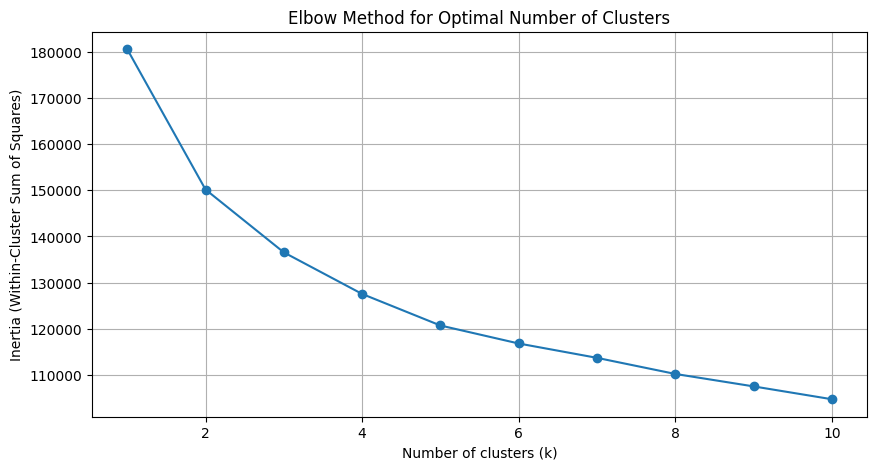

In [20]:
# ---------------------------------------------
# Prepare the feature matrix for clustering
# (K-Means requires scaled features)
# ---------------------------------------------
X = data.drop(columns=['cluster'], errors='ignore')  # remove cluster labels if present
X = X.select_dtypes(include='number')                # keep only numeric features

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ---------------------------------------------
# Elbow Method: compute inertia for k = 1 to 10
# ---------------------------------------------
inertias = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(
        n_clusters=k,
        random_state=0,      # ensures reproducibility
        n_init='auto'        # modern default for stable results
    )
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)

# ---------------------------------------------
# Plot the elbow chart
# ---------------------------------------------
plt.figure(figsize=(10, 5))
plt.plot(K_range, inertias, marker='o')
plt.title("Elbow Method for Optimal Number of Clusters")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia (Within-Cluster Sum of Squares)")
plt.grid(True)
plt.show()

#### 📉 What the elbow chart suggests
The inertia curve drops sharply from k = 1 → 2 → 3, and then the slope begins to flatten around k = 3 or k = 4.<br>
That’s the classic elbow shape: a steep decline followed by diminishing returns.

🔍 Interpretation
- k = 1 → 2 → 3
Each additional cluster dramatically improves the within‑cluster compactness.<br>
This means the data does have meaningful structure beyond a single group.
- k = 3 → 4
The improvement is still noticeable, but much smaller.
This is the “elbow zone”.
- k > 4
The curve flattens significantly.
Adding more clusters gives only marginal gains and risks overfitting.

⭐ Optimal cluster range
Based on the shape of the curve:
The optimal number of clusters is likely between 3 and 4.

In [22]:
# Remove any existing cluster labels to avoid conflicts when re‑running the cell

# data = data.drop('cluster', axis=1) # Place holder cell in case KMeans has to be re-run

def get_clusters(df):
    """
    Assigns each stock to one of four clusters using the K-Means algorithm.

    Notes:
    - The number of clusters (n_clusters=3) was chosen based on prior analysis
      performed above using elbow method.
    - random_state=0 ensures reproducibility so that the clustering results
      remain consistent across runs.
    - init=initial_centroids allows the algorithm to start from predefined
      centroids rather than random initialization, improving stability and
      convergence (will be used at a later step). For now will keep random
      initialization with init='random' 
    """
    df['cluster'] = KMeans(
        n_clusters=3,          # Pre‑determined optimal number of clusters
        random_state=0,        # Ensures deterministic, repeatable clustering
        init='random'          # Using initial_centroids at a later step to use precomputed centroids instead of random seeds
    ).fit(df).labels_
    return df

# Apply clustering separately for each date so that clusters reflect
# the cross‑sectional structure of the market at each point in time.

data = (
    data.dropna()
        .groupby('date', group_keys=False)
        .apply(get_clusters)
)

data

garman_klass_vol        rsi    bb_low    bb_mid   bb_high  \
date       ticker                                                              
2020-01-31 AAPL            0.000533  52.961715  4.284292  4.334739  4.385186   
           ABBV            0.000115  27.244743  4.170257  4.230085  4.289913   
           ABT             0.000153  46.622773  4.332023  4.380803  4.429584   
           ACN             0.000273  45.383511  5.237360  5.257198  5.277035   
           ADBE            0.000161  62.984284  5.805300  5.847616  5.889933   
...                             ...        ...       ...       ...       ...   
2025-12-31 WDAY            0.000065  44.911464  5.361775  5.391165  5.420555   
           WFC             0.000037  66.470638  4.475803  4.527971  4.580139   
           WMT             0.000029  51.483436  4.713338  4.743644  4.773951   
           XOM             0.000046  62.024452  4.743675  4.772225  4.800775   
           XYZ             0.000026  52.186728  4.110362  4.169891  4.229420   

                        atr      macd  return_1m  return_2m  return_3m  \
date       ticker                                                        
2020-01-31 AAPL   -0.918540  0.439820   0.054010   0.076164   0.076627   
           ABBV   -1.165151 -0.715917  -0.072570  -0.032533   0.010633   
           ABT    -1.048554  0.401874   0.007484   0.011983   0.015313   
           ACN    -1.072542  0.059527  -0.021687   0.011967   0.035713   
           ADBE   -1.298629  0.735675   0.064674   0.065096   0.081056   
...                     ...       ...        ...        ...        ...   
2025-12-31 WDAY   -0.943983 -0.452361   0.006075  -0.049118  -0.034105   
           WFC     1.058848  2.039982   0.098544   0.044078   0.041908   
           WMT     1.846088  1.064941   0.014823   0.052807   0.028570   
           XOM     0.376678  0.636144   0.043737   0.033068   0.026766   
           XYZ    -0.877057 -0.006904  -0.018862  -0.070995  -0.032058   

                   return_6m  return_9m  return_12m    Mkt-RF       SMB  \
date       ticker                                                         
2020-01-31 AAPL     0.065435   0.050566    0.054365  1.110234  0.032127   
           ABBV     0.037968   0.007064    0.005453  0.523545 -0.121943   
           ABT      0.001451   0.011508    0.016247  0.787770 -0.138746   
           ACN      0.012016   0.013929    0.025862  1.126785 -0.142075   
           ADBE     0.027233   0.021777    0.029466  1.495064 -0.752004   
...                      ...        ...         ...       ...       ...   
2025-12-31 WDAY    -0.016703  -0.008159   -0.014354  0.550195 -0.526523   
           WFC      0.029453   0.032680    0.026697  1.059425 -0.210499   
           WMT      0.023511   0.028124    0.018810  1.119937 -0.336033   
           XOM      0.022483   0.004936    0.012883  0.491116 -0.560510   
           XYZ     -0.005952   0.021061   -0.021423  1.167559  1.500165   

                        HML       RMW       CMA  cluster  
date       ticker                                         
2020-01-31 AAPL   -0.552994  0.485233  0.164327        0  
           ABBV    0.172767  0.173340  0.742140        2  
           ABT    -0.112885 -0.083543  0.805444        0  
           ACN    -0.197416  0.083491 -0.157896        0  
           ADBE   -0.046524  0.293026 -0.407689        1  
...                     ...       ...       ...      ...  
2025-12-31 WDAY   -0.132930 -1.181537  0.584339        2  
           WFC     0.576516 -1.345766  0.076367        0  
           WMT     0.348750  0.516656 -1.005116        1  
           XOM     1.145011  0.188122 -0.028578        0  
           XYZ    -1.543446 -2.355773  0.753850        1  

[10034 rows x 19 columns]

#### Visualize Clustering

With 18 features in this model it's challenging to visualize all at once. Selecting 2 features, to get a visual cluster grouping.

In [23]:
def plot_clusters(data):
    """
    Visualize K-Means cluster assignments using two selected features.

    Notes:
    - The dataset contains ~18 features, which makes direct visualization
      in higher dimensions impossible.
    - To get an intuitive sense of how the clusters separate, this plot
      uses only two KPIs (column 0 and column 6) as a 2D projection.
    - This does not represent the full clustering structure, but provides
      a useful sanity check on whether clusters show any visible separation.
    """

    # Split the dataset into separate DataFrames for each cluster
    cluster_1 = data[data['cluster'] == 0]
    cluster_2 = data[data['cluster'] == 1]
    cluster_3 = data[data['cluster'] == 2]

    # Scatter plot using two selected KPIs (col 1 vs col 6) RSI vs. ATR 
    # These columns act as a 2D projection of the high-dimensional feature space.
    plt.scatter(cluster_1.iloc[:, 1], cluster_1.iloc[:, 6], color='red',   label='cluster 1')
    plt.scatter(cluster_2.iloc[:, 1], cluster_2.iloc[:, 6], color='green', label='cluster 2')
    plt.scatter(cluster_3.iloc[:, 1], cluster_3.iloc[:, 6], color='blue',  label='cluster 3')

    plt.legend()
    plt.show()
    return

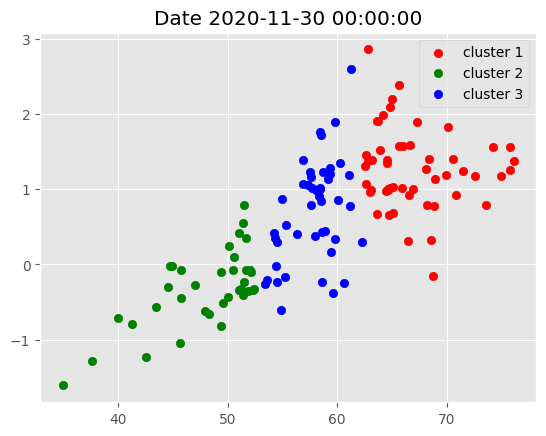

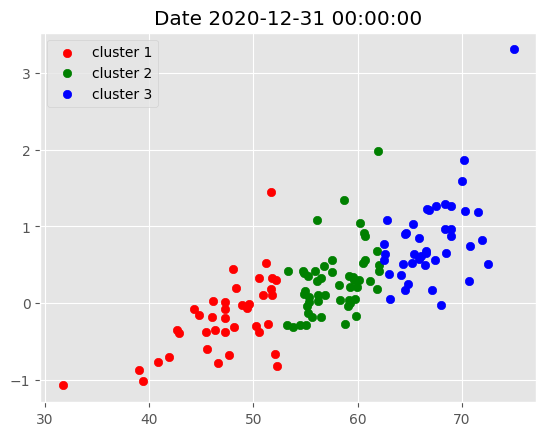

In [24]:
# Creating the plot 

plt.style.use('ggplot')

# Loop through each unique date in the dataset.
# For each date, extract the cross‑section of stocks and visualize the clusters.
# Note:
# - The dataset contains ~18 features, which makes full visualization impossible.
# - To illustrate cluster separation, only two KPIs are plotted (selected inside plot_clusters).
# - Plotting every date produces too many figures, so plotting only two dates at random.

example_dates = data.index.get_level_values('date').unique().tolist()[10:12]

for i in example_dates:
    
    # Extract all stocks for a specific date (cross‑sectional slice)
    g = data.xs(i, level=0)
    
    # Add a title to indicate which date is being visualized
    plt.title(f'Date {i}')
    
    # Plot clusters using two selected KPIs for readability
    plot_clusters(g)

### Optimize KMeans clustering strategy

#### 🎯 Refining the K‑Means Clustering Strategy Using RSI‑Based Initial Centroids

To improve the stability and interpretability of the clustering process, the K‑Means algorithm can be guided by providing<br>
**custom initial centroids** rather than relying on random initialization.  
This refinement leverages the **RSI (Relative Strength Index)** as a proxy for short‑term momentum.

---

#### 📈 Using Momentum to Inform Initial Centroids

Stocks with an RSI around **65–75** typically exhibit **strong upward momentum**.  
These names often represent securities that have been trending positively over the previous month.

The idea is to:

- Identify stocks each month whose RSI falls within the **65–75** range  
- Treat these stocks as belonging to a “momentum‑heavy” region of the feature space  
- Use their feature averages as one of the **initial centroids** for K‑Means  
- Allow the algorithm to build more meaningful clusters by starting from economically informed positions rather than random seeds

This approach helps the clustering algorithm:

- Capture momentum‑driven behaviour more reliably  
- Reduce randomness in cluster formation  
- Improve consistency across monthly cross‑sections  
- Align clusters with intuitive market regimes (e.g., momentum, defensive, value, etc.)

---

#### 🧠 Why Replace Random Initialization?

By default, K‑Means selects initial centroids randomly, which can lead to:

- unstable cluster assignments  
- inconsistent results across runs  
- centroids that start far from meaningful regions of the data  

Providing **RSI‑based initial centroids** gives the algorithm a structured starting point, improving convergence and producing<br>
clusters that better reflect real market behaviour.

---

#### 🧩 Strategy Summary

- Focus on stocks with **RSI ≈ 70**, representing strong upward momentum  
- Use these stocks to compute one or more **initial centroids**  
- Replace the default random initialization with these momentum‑based centroids  
- Run K‑Means with `init=initial_centroids` to guide the clustering process  
- Maintain the same number of clusters (e.g., 3), as determined earlier through cluster‑diagnostic analysis

This refinement helps ensure that stocks with similar momentum characteristics are grouped together from the outset, improving the quality and interpretability of the final clusters.

In [25]:
# Target RSI values used to define momentum‑based initial centroids.
# These represent different momentum regimes:
# - 30  → oversold / weak momentum
# - 45  → neutral to slightly bearish
# - 55  → neutral to slightly bullish
# - 70  → strong upward momentum (the key group of interest)
#
# These values help anchor the centroids in meaningful regions of the feature space,
# instead of relying on random initialization.
target_rsi_values = [45, 55, 70]

# Create an empty centroid matrix with shape:
# (number of centroids) × (number of features)
# Here, the dataset has 18 features, so each centroid is a vector of length 18.
initial_centroids = np.zeros((len(target_rsi_values), 18))

# Place the target RSI values into the RSI feature column.
# Column 6 corresponds to the RSI indicator in your dataset.
# This ensures that one centroid is anchored around RSI ≈ 70 (strong momentum),
# while others represent progressively weaker momentum states.
initial_centroids[:, 6] = target_rsi_values

initial_centroids

array([[ 0.,  0.,  0.,  0.,  0.,  0., 45.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.],
       [ 0.,  0.,  0.,  0.,  0.,  0., 55.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.],
       [ 0.,  0.,  0.,  0.,  0.,  0., 70.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.]])

In [27]:
# Remove any existing cluster labels to avoid conflicts when re‑running the cell

data = data.drop('cluster', axis=1) # Place holder cell in case KMeans has to be re-run

def get_clusters(df):
    """
    Assigns each stock to one of four clusters using the K-Means algorithm.

    Notes:
    - The number of clusters (n_clusters=4) was chosen based on prior analysis
      performed outside this notebook (e.g., elbow method, silhouette score).
    - random_state=0 ensures reproducibility so that the clustering results
      remain consistent across runs.
    - init=initial_centroids allows the algorithm to start from predefined
      centroids rather than random initialization, improving stability and
      convergence.
    """
    df['cluster'] = KMeans(
        n_clusters=3,          # Pre‑determined optimal number of clusters
        random_state=0,        # Ensures deterministic, repeatable clustering
        init=initial_centroids # Use initial_centroids to re-run this cell with precomputed centroids instead of random seeds
    ).fit(df).labels_
    return df

# Apply clustering separately for each date so that clusters reflect
# the cross‑sectional structure of the market at each point in time.

data = (
    data.dropna()
        .groupby('date', group_keys=False)
        .apply(get_clusters)
)

data

garman_klass_vol        rsi    bb_low    bb_mid   bb_high  \
date       ticker                                                              
2020-01-31 AAPL            0.000533  52.961715  4.284292  4.334739  4.385186   
           ABBV            0.000115  27.244743  4.170257  4.230085  4.289913   
           ABT             0.000153  46.622773  4.332023  4.380803  4.429584   
           ACN             0.000273  45.383511  5.237360  5.257198  5.277035   
           ADBE            0.000161  62.984284  5.805300  5.847616  5.889933   
...                             ...        ...       ...       ...       ...   
2025-12-31 WDAY            0.000065  44.911464  5.361775  5.391165  5.420555   
           WFC             0.000037  66.470638  4.475803  4.527971  4.580139   
           WMT             0.000029  51.483436  4.713338  4.743644  4.773951   
           XOM             0.000046  62.024452  4.743675  4.772225  4.800775   
           XYZ             0.000026  52.186728  4.110362  4.169891  4.229420   

                        atr      macd  return_1m  return_2m  return_3m  \
date       ticker                                                        
2020-01-31 AAPL   -0.918540  0.439820   0.054010   0.076164   0.076627   
           ABBV   -1.165151 -0.715917  -0.072570  -0.032533   0.010633   
           ABT    -1.048554  0.401874   0.007484   0.011983   0.015313   
           ACN    -1.072542  0.059527  -0.021687   0.011967   0.035713   
           ADBE   -1.298629  0.735675   0.064674   0.065096   0.081056   
...                     ...       ...        ...        ...        ...   
2025-12-31 WDAY   -0.943983 -0.452361   0.006075  -0.049118  -0.034105   
           WFC     1.058848  2.039982   0.098544   0.044078   0.041908   
           WMT     1.846088  1.064941   0.014823   0.052807   0.028570   
           XOM     0.376678  0.636144   0.043737   0.033068   0.026766   
           XYZ    -0.877057 -0.006904  -0.018862  -0.070995  -0.032058   

                   return_6m  return_9m  return_12m    Mkt-RF       SMB  \
date       ticker                                                         
2020-01-31 AAPL     0.065435   0.050566    0.054365  1.110234  0.032127   
           ABBV     0.037968   0.007064    0.005453  0.523545 -0.121943   
           ABT      0.001451   0.011508    0.016247  0.787770 -0.138746   
           ACN      0.012016   0.013929    0.025862  1.126785 -0.142075   
           ADBE     0.027233   0.021777    0.029466  1.495064 -0.752004   
...                      ...        ...         ...       ...       ...   
2025-12-31 WDAY    -0.016703  -0.008159   -0.014354  0.550195 -0.526523   
           WFC      0.029453   0.032680    0.026697  1.059425 -0.210499   
           WMT      0.023511   0.028124    0.018810  1.119937 -0.336033   
           XOM      0.022483   0.004936    0.012883  0.491116 -0.560510   
           XYZ     -0.005952   0.021061   -0.021423  1.167559  1.500165   

                        HML       RMW       CMA  cluster  
date       ticker                                         
2020-01-31 AAPL   -0.552994  0.485233  0.164327        2  
           ABBV    0.172767  0.173340  0.742140        0  
           ABT    -0.112885 -0.083543  0.805444        2  
           ACN    -0.197416  0.083491 -0.157896        2  
           ADBE   -0.046524  0.293026 -0.407689        1  
...                     ...       ...       ...      ...  
2025-12-31 WDAY   -0.132930 -1.181537  0.584339        0  
           WFC     0.576516 -1.345766  0.076367        1  
           WMT     0.348750  0.516656 -1.005116        2  
           XOM     1.145011  0.188122 -0.028578        1  
           XYZ    -1.543446 -2.355773  0.753850        2  

[10034 rows x 19 columns]

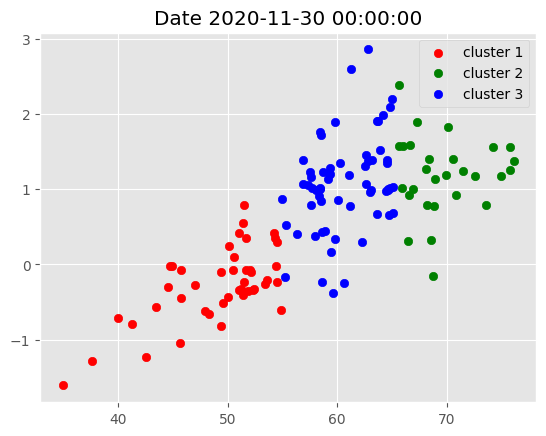

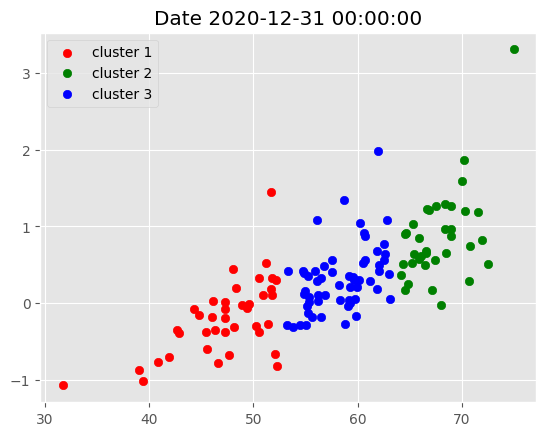

In [28]:
# Re-run the plots 

# Creating the plot 

plt.style.use('ggplot')

# Loop through each unique date in the dataset.
# For each date, extract the cross‑section of stocks and visualize the clusters.
# Note:
# - The dataset contains ~18 features, which makes full visualization impossible.
# - To illustrate cluster separation, only two KPIs are plotted (selected inside plot_clusters).
# - Plotting every date produces too many figures, so plotting only two dates at random.

example_dates = data.index.get_level_values('date').unique().tolist()[10:12]

for i in example_dates:
    
    # Extract all stocks for a specific date (cross‑sectional slice)
    g = data.xs(i, level=0)
    
    # Add a title to indicate which date is being visualized
    plt.title(f'Date {i}')
    
    # Plot clusters using two selected KPIs for readability
    plot_clusters(g)

### 📈 Portfolio Optimization Strategy

At the start of each new month, the goal is to select the stocks that will be held in the portfolio for the following month.  
The selection process is driven by the clustering results and then refined using an Efficient Frontier optimization based on the **maximum Sharpe ratio**.

---

#### 🎯 Cluster‑Driven Asset Selection

The first step is to filter the universe of stocks based on the cluster assignments.  
Only the stocks belonging to the cluster that aligns with the investment hypothesis are considered for inclusion in the portfolio.

The working hypothesis is grounded in momentum behaviour:

- Stocks with an **RSI around 70** typically exhibit strong upward momentum  
- Momentum tends to be **persistent**, meaning stocks that have recently shown strength often continue to outperform in the near term  
- The cluster whose centroid is anchored around **RSI ≈ 70** (e.g., *cluster 3*) is therefore expected to contain stocks with favourable momentum characteristics

Under this hypothesis, the portfolio construction process focuses on the stocks assigned to **cluster 3** each month.

---

#### 🧠 Momentum Hypothesis

**Hypothesis:**  
Stocks with an RSI near 70 are experiencing strong upward momentum, and this momentum is likely to continue into the following month.  
Therefore, selecting stocks from the cluster associated with this momentum regime should improve forward‑looking performance.

---

#### 📊 Efficient Frontier Optimization

Once the monthly stock subset is identified, an Efficient Frontier optimization is applied:

- Use only the stocks from the selected cluster  
- Estimate expected returns and covariance based on historical data  
- Compute the Efficient Frontier  
- Select the portfolio that maximizes the **Sharpe ratio**  
- Allocate weights accordingly for the next month

This approach blends **unsupervised learning** (to identify favourable momentum regimes) with **quantitative portfolio optimization** (to allocate capital efficiently within that regime).

---

#### 📦 Preparing Monthly Stock Lists

To support the monthly rebalancing workflow, a dictionary is created where:

- Each key corresponds to a month  
- Each value contains the list of stocks selected from the chosen cluster for that month  

This structure makes it easy to iterate through months, run optimizations, and evaluate performance over time.

In [29]:
# Filter the dataset to include only the stocks belonging to the chosen cluster.
# Cluster 3 corresponds to the RSI≈70 momentum regime identified earlier.
filtered_df = data[data['cluster'] == 2].copy()

# Reset the ticker level of the MultiIndex so that 'ticker' becomes a column.
# This makes it easier to shift dates and reassign the index later.
filtered_df = filtered_df.reset_index(level=1)

# Shift all dates forward by one month.
# This aligns with the investment rule:
# "At the beginning of each month, select the stocks to invest in for the following month."
filtered_df.index = filtered_df.index + pd.DateOffset(1)

# Rebuild the MultiIndex using the shifted dates and the ticker column.
filtered_df = (
    filtered_df
    .reset_index()
    .set_index(['date', 'ticker'])
)

# Extract the list of unique dates after shifting.
dates = filtered_df.index.get_level_values('date').unique().tolist()

# Create a dictionary mapping each month to the list of stocks
# that belong to the selected cluster for that month.
# This structure will be used to run monthly portfolio optimization.
fixed_dates = {}

for d in dates:
    # Convert the date to a clean string format for dictionary keys
    fixed_dates[d.strftime('%Y-%m-%d')] = (
        filtered_df.xs(d, level=0).index.tolist()
    )

fixed_dates

{'2020-02-01': ['AAPL',
  'ABT',
  'ACN',
  'ADP',
  'AMD',
  'AMT',
  'AVGO',
  'AXP',
  'BA',
  'BDX',
  'BLK',
  'BMY',
  'BRK-B',
  'CMG',
  'COST',
  'CSX',
  'DHR',
  'EA',
  'GILD',
  'GOOG',
  'GOOGL',
  'GS',
  'HD',
  'INTC',
  'INTU',
  'JPM',
  'LRCX',
  'LULU',
  'MA',
  'MDT',
  'MS',
  'MU',
  'NFLX',
  'NOC',
  'NVDA',
  'NXPI',
  'PANW',
  'PG',
  'PYPL',
  'RTX',
  'T',
  'TMUS',
  'ULTA',
  'UNP',
  'V',
  'VRTX',
  'VZ'],
 '2020-03-01': ['ABBV',
  'ADBE',
  'ADSK',
  'AMAT',
  'AMD',
  'AMT',
  'AMZN',
  'AZO',
  'BDX',
  'BIIB',
  'BKNG',
  'CHTR',
  'CI',
  'CRM',
  'DE',
  'EA',
  'EBAY',
  'ELV',
  'FDX',
  'GE',
  'GOOG',
  'GOOGL',
  'HON',
  'INTU',
  'LRCX',
  'MA',
  'MAR',
  'META',
  'MMM',
  'MPC',
  'MSFT',
  'MU',
  'NEE',
  'PM',
  'PYPL',
  'QCOM',
  'SCHW',
  'TJX',
  'TSLA',
  'TXN',
  'ULTA',
  'UNH',
  'V',
  'VRTX',
  'WDAY'],
 '2020-04-01': ['AAPL',
  'ABBV',
  'ACN',
  'ADBE',
  'ADP',
  'ADSK',
  'ALGN',
  'AMAT',
  'AMT',
  'AZO',
  'BKNG',


### 📊 Portfolio Optimization and Monthly Weight Assignment

At the beginning of each month, a new list of eligible stocks is available based on the clustering process.  
The next step is to assign portfolio weights to these stocks in a systematic and quantitative way.  
This is achieved through an optimization framework that selects weights using <br>
the **Efficient Frontier** and the **maximum Sharpe ratio** criterion.

---

#### 📈 Monthly Optimization Workflow

1. **Select the stocks for the upcoming month**  
   These stocks come from the cluster identified as having the strongest momentum characteristics  
   (e.g., the cluster centered around RSI ≈ 70).

2. **Estimate expected returns**  
   Expected returns are computed using **mean historical returns** with a frequency<br> 
   of 252 trading days (representing one year of daily data).  
   This provides a forward‑looking estimate based on recent performance.

3. **Compute the covariance matrix**  
   The covariance of asset returns is estimated using historical price data.  
   This captures how the selected stocks move relative to one another and is essential<br> 
   for risk‑aware optimization.

4. **Initialize the Efficient Frontier**  
   The Efficient Frontier model is constructed using the expected returns and covariance matrix.  
   The optimization is configured with:
   - **solver='SCS'**: a robust convex optimization solver well‑suited for portfolio problems  
     (it handles constraints reliably and avoids numerical instability)
   - **weight_bounds**: lower and upper bounds on individual asset weights  
     These bounds may be refined later depending on diversification goals or concentration limits.

5. **Optimize for maximum Sharpe ratio**  
   The optimizer selects the portfolio that maximizes risk‑adjusted return, producing a set of weights  
   for the stocks to be held during the following month.

---

#### 📦 Output Structure

The optimization function returns a clean dictionary of weights, which can be stored, tracked,  
and used to evaluate portfolio performance over time.

In [30]:
def optimize_weights(prices, lower_bound=0):
    """
    Optimize portfolio weights for a given set of stock prices using
    Efficient Frontier maximum Sharpe ratio optimization.

    Parameters
    ----------
    prices : DataFrame
        Historical price data for the selected stocks.
    lower_bound : float
        Minimum weight allowed for each asset (default = 0 for long-only portfolios).

    Notes
    -----
    - Expected returns are computed using mean historical returns with frequency=252,
      representing one year of daily trading data.
    - The covariance matrix is estimated using sample covariance, also annualized.
    - The Efficient Frontier is initialized with:
        * weight_bounds = (lower_bound, 0.1)
          This caps individual positions at 10% to avoid concentration.
          These bounds may be revisited later depending on diversification needs.
        * solver = 'SCS'
          A stable convex optimization solver that handles constraints reliably.
    - The optimizer selects the portfolio with the maximum Sharpe ratio.
    """

    # Estimate expected annual returns using historical mean returns
    returns = expected_returns.mean_historical_return(
        prices=prices,
        frequency=252
    )

    # Estimate annualized covariance matrix of returns
    cov = risk_models.sample_cov(
        prices=prices,
        frequency=252
    )

    # Initialize the Efficient Frontier with constraints and solver choice
    ef = EfficientFrontier(
        expected_returns=returns,
        cov_matrix=cov,
        weight_bounds=(lower_bound, 0.1),
        solver='SCS'
    )

    # Optimize for maximum Sharpe ratio
    weights = ef.max_sharpe()

    # Return cleaned weights (rounded and filtered)
    return ef.clean_weights()

In [31]:
# Extract the full list of unique tickers from the dataset.
# These represent all stocks that ever appeared in the selected cluster
# and may be needed for price retrieval.
stocks = data.index.get_level_values('ticker').unique().tolist()

# Download fresh daily price data for the shortlisted stocks.
# The date range is chosen to ensure:
# - At least 12 months of historical data before the first optimization date
#   (needed for expected returns and covariance estimation)
# - Up to the last date present in the dataset
new_df = yf.download(
    tickers=stocks,
    start=data.index.get_level_values('date').unique()[0] - pd.DateOffset(months=12),
    end=data.index.get_level_values('date').unique()[-1]
)

new_df.head()

[*********************100%***********************]  151 of 151 completed


Price           Close                                                     \
Ticker           AAPL       ABBV ABNB        ABT         ACN        ADBE   
Date                                                                       
2019-01-31  39.527103  59.502747  NaN  64.544098  138.912338  247.820007   
2019-02-01  39.546108  59.658394  NaN  63.995777  139.988876  247.380005   
2019-02-04  40.669399  58.198425  NaN  64.119591  141.626312  254.740005   
2019-02-05  41.365231  59.058105  NaN  64.659073  142.322983  254.820007   
2019-02-06  41.379494  58.606018  NaN  64.995125  142.178192  254.350006   

Price                                                      ...    Volume  \
Ticker            ADI         ADP        ADSK        ALGN  ...         V   
Date                                                       ...             
2019-01-31  86.700836  120.581253  147.199997  248.949997  ...  20095700   
2019-02-01  88.174187  122.116135  149.070007  244.000000  ...  13248300   
2019-02-04  87.437515  123.849297  151.589996  244.539993  ...  11882700   
2019-02-05  88.051414  125.280685  152.419998  243.509995  ...   8455700   
2019-02-06  89.814178  125.496254  152.279999  244.039993  ...   6146900   

Price                                                                         \
Ticker          VLO     VRTX        VZ     WDAY       WFC       WMT     WYNN   
Date                                                                           
2019-01-31  8796700   900800  28585400  3165900  24934700  44169000  3719800   
2019-02-01  5136100   892800  13778000  2477700  21123500  37775700  2990800   
2019-02-04  4448500  1482300  15818900  1797500  17547800  21805800  1210900   
2019-02-05  3918400  1643500  14124600  2041900  14784900  18299700  1946600   
2019-02-06  2783900  1915700  11391400  1189500  12145700  12794700  2418700   

Price                           
Ticker           XOM       XYZ  
Date                            
2019-01-31  19876700  15679400  
2019-02-01  22968700  12677800  
2019-02-04  15483800  10582100  
2019-02-05  12786700  19150500  
2019-02-06  10866900  10068500  

[5 rows x 755 columns]

#### Explanation of Portfolio Strategy 

#### 📈 1. Compute Daily Returns
Daily log returns are calculated for every stock that could appear in the portfolio.
These returns will later be combined with monthly weights to compute daily portfolio performance.

#### 🕒 2. Loop Through Each Monthly Rebalancing Date
For each month:
- Identify the stocks selected by the clustering model
- Gather one year of historical prices prior to the rebalancing date
- This 12‑month window is essential because the Efficient Frontier requires:
- mean historical returns
- covariance matrix
- volatility estimates
- These inputs are sourced from new_df, which contains the fresh daily prices downloaded earlier.

#### 🧮 3. Optimize Portfolio Weights

For each month:
- Run the optimize_weights() function using the 12‑month price window
- If the optimization succeeds, use the maximum‑Sharpe weights
- If it fails (e.g., due to singular covariance matrices or insufficient data), fall back to equal‑weighted allocation

This ensures the backtest continues smoothly without interruptions.

#### 💰 4. Compute Daily Portfolio Returns
Once weights are determined:
- Extract daily returns for the selected stocks during the holding month
- Multiply each stock’s return by its assigned weight
- Sum across all stocks to obtain the daily portfolio return
- Append results to a master portfolio_df for performance analysis
This structure allows you to evaluate the strategy’s performance across time, including cumulative returns, drawdowns, and Sharpe ratios.

In [ ]:
# 1) Use Close prices and flatten MultiIndex

close_prices = new_df['Close'].copy()

# Flatten columns so only tickers remain (no 'Close' level leaking into stack)

close_prices.columns = close_prices.columns.get_level_values(0)

# Compute daily log returns

returns_dataframe = np.log(close_prices).diff()


# 2) Initialize portfolio return container

portfolio_df = pd.DataFrame()


# 3) Monthly rebalancing loop

for start_date in fixed_dates.keys():
    try:
        start_dt = pd.to_datetime(start_date)
        end_dt = start_dt + pd.offsets.MonthEnd(0)

        # Stocks selected for this month
        cols = fixed_dates[start_date]

        # Optimization window: 12 months before start_date
        optimization_start_date = (start_dt - pd.DateOffset(months=12)).strftime('%Y-%m-%d')
        optimization_end_date   = (start_dt - pd.DateOffset(days=1)).strftime('%Y-%m-%d')

        # Extract price history for selected stocks
        optimization_df = close_prices.loc[optimization_start_date:optimization_end_date, cols]

        # Try Max Sharpe optimization
        success = False
        try:
            lower_bound = round(1 / (len(optimization_df.columns) * 2), 3)

            weights_dict = optimize_weights(
                prices=optimization_df,
                lower_bound=lower_bound
            )

            # Convert dict → Series for alignment
            weights = pd.Series(weights_dict)
            success = True

        except Exception:
            print(f"Max Sharpe Optimization failed for {start_date}, using equal weights.")

        # Fallback: equal weights
        if not success:
            weights = pd.Series(
                1 / len(optimization_df.columns),
                index=optimization_df.columns
            )

        # Ensure numeric dtype
        weights = weights.astype(float)

        # Compute daily portfolio returns for holding month
        period_returns = returns_dataframe.loc[start_dt:end_dt, cols].astype(float)

        # Weighted daily returns
        daily_portfolio_returns = (period_returns * weights).sum(axis=1)
        daily_portfolio_returns = daily_portfolio_returns.to_frame('Strategy Return')

        # Append to master portfolio DataFrame
        portfolio_df = pd.concat([portfolio_df, daily_portfolio_returns], axis=0)

    except Exception as e:
        print(e)


# 4) Remove any duplicated dates

portfolio_df = portfolio_df[~portfolio_df.index.duplicated(keep='first')]

portfolio_df

,Strategy Return
Date,
2020-02-03,0.003380
2020-02-04,0.016790
2020-02-05,0.002482
2020-02-06,0.006895
2020-02-07,-0.002132
...,...
2025-12-23,0.001052
2025-12-24,0.007381
2025-12-26,-0.000824


### 📊 Comparing Strategy Returns to the S&P 500

To evaluate the performance of the momentum‑based clustering strategy, we compare its daily returns to a broad market<br> 
benchmark — the S&P 500 (via the SPY ETF).  
This allows us to understand whether the strategy adds value beyond simply holding the market.

The steps are:

1. Download daily price data for SPY over the full backtest period.  
2. Compute daily log returns for SPY.  
3. Merge SPY returns with the strategy’s daily returns.  
4. Use this combined dataset to visualize performance, compute cumulative returns, and assess relative strength.

This comparison provides a clear view of whether the strategy outperforms, matches, or lags the market over time.

In [41]:
# Download SPY price data
spy = yf.download(
    tickers='SPY',
    start='2015-01-01',
    end=dt.date.today()
)

# Extract Close prices and flatten to a Series
spy_close = spy['Close'].copy()

# If spy_close is a DataFrame (MultiIndex), convert it to a Series
if isinstance(spy_close, pd.DataFrame):
    spy_close = spy_close.iloc[:, 0]   # take the first column
    spy_close.name = 'SPY Close'
else:
    spy_close.name = 'SPY Close'

# Compute daily log returns for SPY
spy_ret = (
    np.log(spy_close).diff()
    .dropna()
    .rename('SPY Buy&Hold')
    .to_frame()
)

# Merge SPY returns with the strategy's daily returns
portfolio_df = portfolio_df.merge(
    spy_ret,
    left_index=True,
    right_index=True,
    how='inner'
)

portfolio_df

[*********************100%***********************]  1 of 1 completed


,Strategy Return,SPY Buy&Hold
Date,,
2020-02-03,0.003380,0.007401
2020-02-04,0.016790,0.015126
2020-02-05,0.002482,0.011482
2020-02-06,0.006895,0.003359
2020-02-07,-0.002132,-0.005344
...,...,...
2025-12-23,0.001052,0.004560
2025-12-24,0.007381,0.003511
2025-12-26,-0.000824,-0.000101


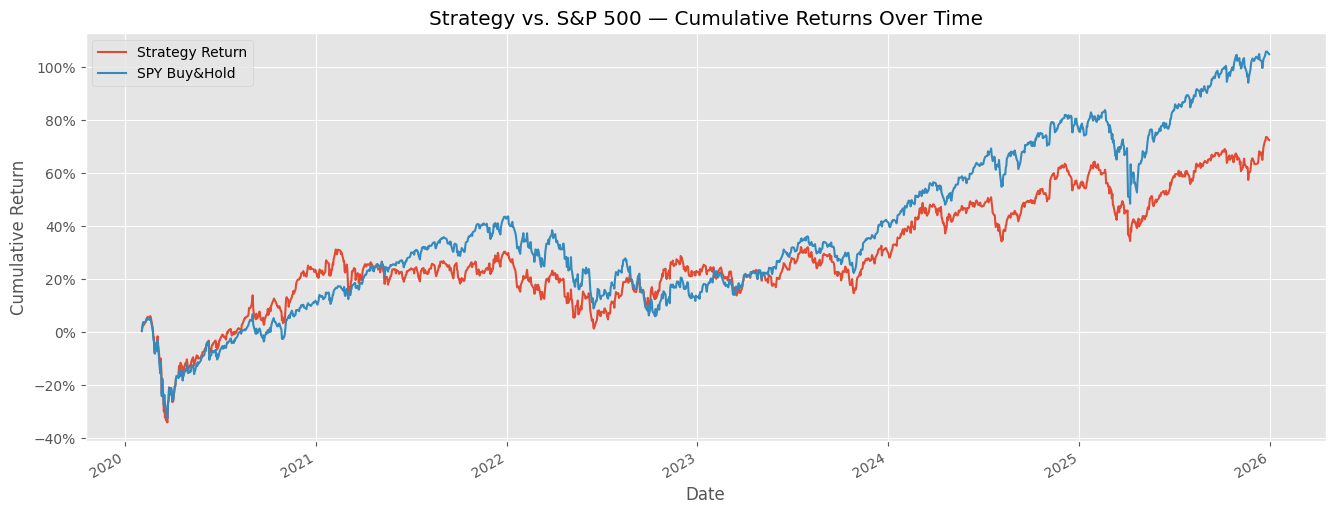

In [42]:
import matplotlib.ticker as mtick
plt.style.use('ggplot')

# Compute cumulative returns from daily returns
# Using log1p ensures numerical stability for small returns
portfolio_cumulative_return = np.exp(np.log1p(portfolio_df).cumsum()) - 1

# Plot cumulative returns
fig, ax = plt.subplots(figsize=(16, 6))

portfolio_cumulative_return.plot(ax=ax)

ax.set_title('Strategy vs. S&P 500 — Cumulative Returns Over Time')
ax.set_ylabel('Cumulative Return')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1))  # format as percentages

plt.show()

### 📌 Final Remarks

This project brought together several layers of quantitative analysis — from feature engineering and unsupervised learning to portfolio construction and performance evaluation. By combining momentum‑based clustering with an Efficient Frontier optimization framework, the workflow demonstrates how machine learning techniques can be integrated into a systematic investment process.

The results show that while the strategy captures meaningful structure in the data and produces coherent momentum‑driven portfolios, it does not consistently outperform a broad market benchmark such as the S&P 500. This outcome is valuable in itself: it highlights the importance of rigorous testing, realistic assumptions, and the gap that often exists between theoretical signals and real‑world performance.

There are several natural extensions that could be explored in future iterations:

- **Feature expansion:** incorporating volatility measures, volume‑based indicators, or macroeconomic factors.  
- **Alternative clustering methods:** such as Gaussian Mixture Models, HDBSCAN, or spectral clustering to capture non‑linear structure.  
- **Regime detection:** adapting cluster selection or optimization rules depending on market conditions.  
- **Transaction costs and slippage:** integrating realistic frictions to evaluate robustness.  
- **Alternative optimization objectives:** such as risk parity, minimum volatility, or hierarchical risk parity.

Overall, this project demonstrates a full end‑to‑end workflow — data ingestion, feature engineering, clustering, portfolio optimization, and performance visualization — and provides a strong foundation for more advanced research or production‑grade enhancements.